In [ ]:
import pandas as pd

df = pd.read_csv('MarketingCaseStudy.csv')

In [ ]:
df.shape

(618875, 12)

In [ ]:
df.dtypes

Unnamed: 0                                   int64
flag                                        object
Date                                        object
country                                     object
deviceType                                  object
sessionId                                   object
signups                                    float64
sessionDurationInSeconds                     int64
PageViews                                    int64
subscriptionsTotalByCycle                   object
subscriptionsTotal                         float64
subscriptionBillingsConvertedInCHFTotal    float64
dtype: object

In [ ]:
#index column not needed in the analysis, droping the column
df.drop(columns=['Unnamed: 0'], inplace=True)


In [ ]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Clean 'subscriptionsTotalByCycle' to remove '{}' and keep only string content inside
df['subscriptionsTotalByCycle_clean'] = (df['subscriptionsTotalByCycle']
    .str.extract(r'\{(.*)\}')[0]  # Extract the first (and only) capture group
    .replace('', pd.NA)
)


In [ ]:
# count of subscriptionsTotalByCycle_clean values including NA
df['subscriptionsTotalByCycle_clean'].value_counts(dropna=False)

subscriptionsTotalByCycle_clean
<NA>               606452
1: 1.0               7727
12: 1.0              2588
24: 1.0              1934
3: 1.0                145
1: 2.0                 17
12: 3.0                 4
1: 3.0                  3
1: 1.0, 12: 1.0         2
1: 5.0                  1
12: 2.0                 1
1: 1.0, 24: 1.0         1
Name: count, dtype: int64

In [ ]:
# Deduplicating based on sessionId
# deduplicate while preserving the session with highest signups or subscriptions if there are multiple
df_sorted = df.sort_values(
    by=[
        'sessionId','subscriptionBillingsConvertedInCHFTotal','subscriptionsTotal','signups','sessionDurationInSeconds','PageViews'],
    ascending=[True, False, False, False, False, False]
)

df_deduplicated = df_sorted.drop_duplicates(subset='sessionId', keep='first').reset_index(drop=True)

df_deduplicated.shape # 29821 duplicates removed

(589054, 12)

In [ ]:
df_deduplicated.describe()

,Date,signups,sessionDurationInSeconds,PageViews,subscriptionsTotal,subscriptionBillingsConvertedInCHFTotal
count,589054,589054.000000,589054.000000,589054.000000,589054.000000,589054.000000
mean,2025-04-01 23:35:22.240744960,0.268444,256.016481,4.198629,0.021102,0.683573
min,2025-03-26 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2025-03-30 00:00:00,0.000000,17.000000,2.000000,0.000000,0.000000
50%,2025-04-02 00:00:00,0.000000,80.000000,4.000000,0.000000,0.000000
75%,2025-04-05 00:00:00,1.000000,263.000000,5.000000,0.000000,0.000000
max,2025-04-09 00:00:00,7.000000,56328.000000,254.000000,3.000000,547.120000
std,NaN,0.461017,481.702823,3.204303,0.144219,7.444938


In [ ]:
#Droping rows with missing country to calculate Conversions at Country level
df_cleaned = df_deduplicated.dropna(subset=['country'])
df_cleaned.shape

(588788, 12)

In [ ]:
df_cleaned['flag'].value_counts()

flag
C    200502
A    194360
B    193926
Name: count, dtype: int64

In [ ]:
# Calculating number of sessions with at least one signup
sessions_with_signup = (df_deduplicated['signups'] > 0).sum()

# Total sessions
total_sessions = df_deduplicated.shape[0]

(sessions_with_signup, total_sessions)





(153773, 589054)

In [ ]:
country_counts = df_deduplicated['country'].value_counts()

#Set minimum threshold of 1000 and 100 for reference
min_threshold = 1000
valid_countries = country_counts[country_counts >= min_threshold].index

# Step 3: Calculate binary conversion rate (sessions with signups > 0) per country
df_deduplicated.loc[:, 'converted'] = (df_deduplicated['signups'] > 0).astype(int)

# Step 4: Filter dataset to valid countries
df_valid = df_deduplicated[df_deduplicated['country'].isin(valid_countries)]

# Step 5: Group and calculate conversion rate per country
cr_summary = (
    df_valid.groupby('country').agg(total_sessions=('sessionId', 'count'), converted_sessions=('converted', 'sum'))
    .assign(conversion_rate_pct=lambda x: round((x['converted_sessions'] / x['total_sessions']) * 100, 2)
    ).sort_values(by='conversion_rate_pct', ascending=False)
)
cr_summary.head(40)

,total_sessions,converted_sessions,conversion_rate_pct
country,,,
ARG,4675,1699,36.34
COL,4410,1520,34.47
ZAF,2683,923,34.40
LKA,1053,362,34.38
PHL,7863,2624,33.37
IRL,1741,564,32.40
NGA,2581,836,32.39
KEN,2148,688,32.03
ECU,1416,453,31.99


In [ ]:
cr_summary.tail(5)

,total_sessions,converted_sessions,conversion_rate_pct
country,,,
CHN,424,61,14.39
MMR,182,25,13.74
JOR,162,18,11.11
QAT,433,40,9.24
OMN,1105,52,4.71


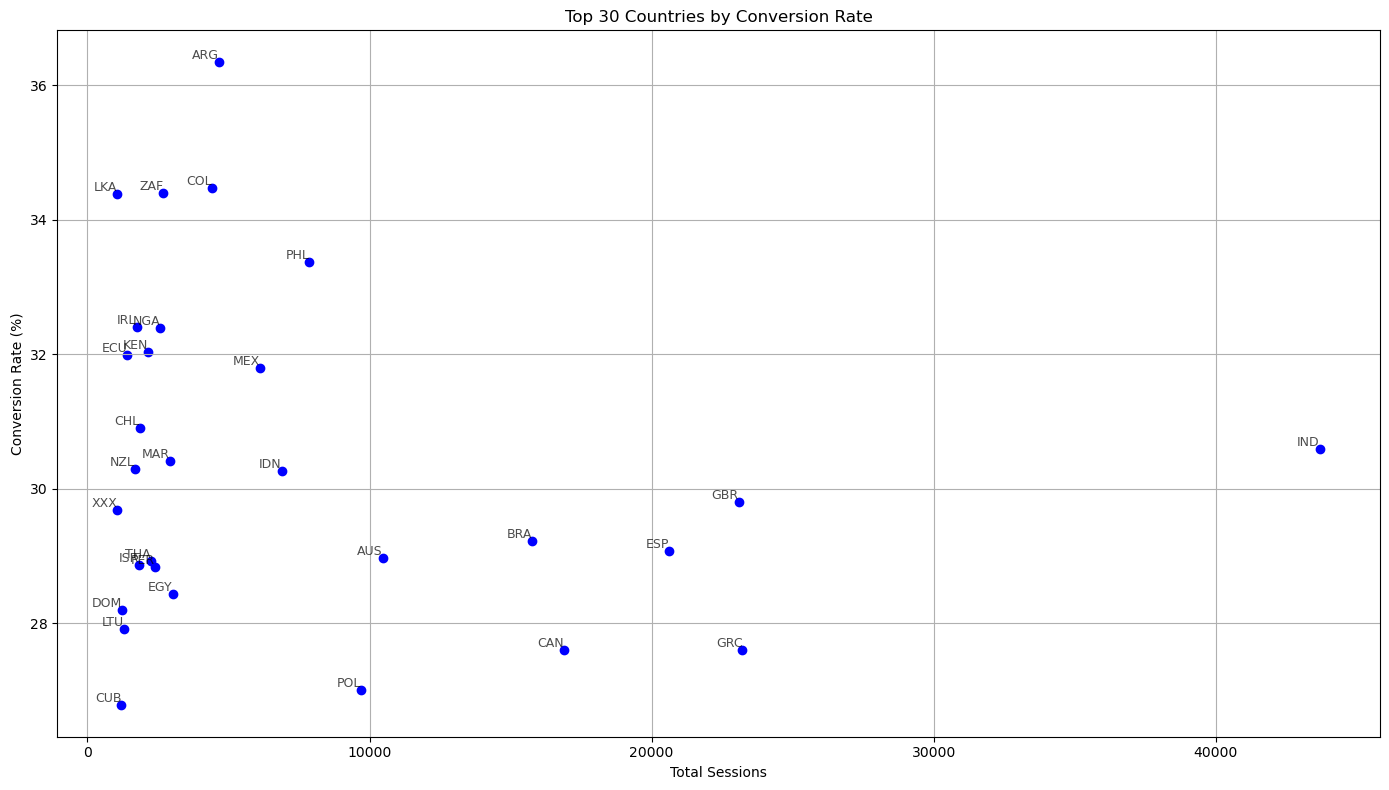

In [ ]:
#plot the top 30 countries signup rates with a minimum of 1000 sessions
import matplotlib.pyplot as plt

top30 = cr_summary.head(30).reset_index()

# Plot
plt.figure(figsize=(14, 8))
plt.scatter(top30['total_sessions'], top30['conversion_rate_pct'], color='blue')

# Add annotations for each point
for i in range(top30.shape[0]):
    plt.text(top30['total_sessions'][i], top30['conversion_rate_pct'][i], top30['country'][i], fontsize=9, ha='right', va='bottom', alpha=0.7)

plt.title('Top 30 Countries by Conversion Rate')
plt.xlabel('Total Sessions')
plt.ylabel('Conversion Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#calculating the signup conversion rates across each variants
df_deduplicated.loc[:, 'converted'] = (df_deduplicated['signups'] > 0).astype(int)

variant_cr = (
    df_deduplicated.groupby('flag').agg(total_sessions=('sessionId', 'count'), converted_sessions=('converted', 'sum'))
    .assign(conversion_rate_pct=lambda x: round((x['converted_sessions'] / x['total_sessions']) * 100, 2)
    ).sort_values(by='flag', ascending=True)
)
variant_cr

,total_sessions,converted_sessions,conversion_rate_pct
flag,,,
A,194446,50873,26.16
B,194025,50258,25.90
C,200583,52642,26.24


In [ ]:
#import statsmodels library for z-tests
from statsmodels.stats.proportion import proportions_ztest

# Define counts and sample sizes for Control (A) vs B and A vs C
control_sessions = variant_cr.loc['A', 'total_sessions']
control_converted = variant_cr.loc['A', 'converted_sessions']

b_sessions = variant_cr.loc['B', 'total_sessions']
b_converted = variant_cr.loc['B', 'converted_sessions']

c_sessions = variant_cr.loc['C', 'total_sessions']
c_converted = variant_cr.loc['C', 'converted_sessions']

# Z-test for A vs B
count_ab = [control_converted, b_converted]
nobs_ab = [control_sessions, b_sessions]
stat_ab, pval_ab = proportions_ztest(count_ab, nobs_ab)

# Z-test for A vs C
count_ac = [control_converted, c_converted]
nobs_ac = [control_sessions, c_sessions]
stat_ac, pval_ac = proportions_ztest(count_ac, nobs_ac)

(stat_ab, pval_ab), (stat_ac, pval_ac)

((1.8478860990215367, 0.0646188219085682),
 (-0.5819931491582273, 0.5605712954521311))

Statistical significance test (Z-test)
Control A vs Variant B
Z-statistic: 1.85, p-value: 0.065
Slightly above the threshold of 0.05. (Not statistically significant and hence we cannot say variant B performs different from Control A

Control A vs Variant C
Z-statistic: -0.58, p-value: 0.561
Not significant. The slight uplift in Variant C conversion rate over A is not statistically significant and could be due to random chance.

In [ ]:
# Calculating the overall conversion rate using deduplicated data
df_deduplicated['converted'] = (df_deduplicated['signups'] > 0).astype(int)

# Calculating overall conversion rate as a percentage
overall_cr_pct = round(df_deduplicated['converted'].mean() * 100, 2)
overall_total_sessions = df_deduplicated.shape[0]
overall_converted_sessions = df_deduplicated['converted'].sum()

overall_total_sessions, overall_converted_sessions, overall_cr_pct

(589054, 153773, 26.11)

In [ ]:
# Creating a binary conversion column if not already present
df_deduplicated['converted'] = (df_deduplicated['signups'] > 0).astype(int)

# Group by variant (flag) and deviceType, then aggregate
variant_device_summary = (df_deduplicated.groupby(['flag', 'deviceType']).agg(
        total_sessions=('sessionId', 'count'), converted_sessions=('converted', 'sum')
    ).assign(conversion_rate_pct=lambda x: round((x['converted_sessions'] / x['total_sessions']) * 100, 2)
    ).reset_index()
)

# Pivot the data for easier comparison
pivoted_summary = variant_device_summary.pivot(index='flag', columns='deviceType', values=['total_sessions', 'conversion_rate_pct'])

# Flatten MultiIndex columns
pivoted_summary.columns = [f'{stat}_{device}' for stat, device in pivoted_summary.columns]
pivoted_summary = pivoted_summary.reset_index()

pivoted_summary

,flag,total_sessions_desktop,total_sessions_phone,conversion_rate_pct_desktop,conversion_rate_pct_phone
0,A,148580.0,45866.0,27.31,22.46
1,B,147838.0,46187.0,27.01,22.36
2,C,153076.0,47507.0,27.35,22.70


In [ ]:

# Filter valid countries
df_country_variant = df_deduplicated[df_deduplicated['country'].notnull()].copy()

# Count sessions per (country, flag)
country_variant_counts = df_country_variant.groupby(['country', 'flag'])['sessionId'].count().reset_index(name='session_count')

# Filter for (country, flag) pairs with at least 1000 sessions
valid_pairs = country_variant_counts[country_variant_counts['session_count'] >= 500]
df_valid_cv = df_country_variant.merge(valid_pairs[['country', 'flag']], on=['country', 'flag'])

# Add binary converted column
df_valid_cv['converted'] = (df_valid_cv['signups'] > 0).astype(int)

# Group by country and flag
summary = (
    df_valid_cv.groupby(['country', 'flag']).agg(sessions=('sessionId', 'count'),
        conversion_rate_pct=('converted', lambda x: round(x.mean() * 100, 2))
    )
    .reset_index()
)

# Pivot for side-by-side comparison
pivoted_summary = summary.pivot(index='country', columns='flag', values=['sessions', 'conversion_rate_pct'])
pivoted_summary.columns = [f'{stat}_{variant}' for stat, variant in pivoted_summary.columns]
pivoted_summary = pivoted_summary.reset_index()


pivoted_summary.head(20)


,country,sessions_A,sessions_B,sessions_C,conversion_rate_pct_A,conversion_rate_pct_B,conversion_rate_pct_C
0,ARE,906.0,863.0,917.0,27.37,23.41,23.23
1,ARG,1528.0,1537.0,1610.0,35.08,36.69,37.20
2,AUS,3421.0,3413.0,3627.0,28.82,28.10,29.94
3,AUT,988.0,914.0,929.0,18.93,21.99,20.13
4,BEL,1099.0,1092.0,1148.0,25.57,26.01,24.04
5,BGD,1279.0,1201.0,1336.0,26.82,24.56,24.55
6,BRA,5220.0,5252.0,5275.0,28.56,29.23,29.88
7,CAN,5549.0,5534.0,5796.0,27.48,27.05,28.23
8,CHE,1774.0,1774.0,1837.0,16.97,16.80,15.84
9,CHL,627.0,588.0,642.0,33.17,29.08,30.37


In [ ]:
# Calculating deltas between A vs B and A vs C
pivoted_summary['delta_A_vs_B'] = pivoted_summary['conversion_rate_pct_A'] - pivoted_summary['conversion_rate_pct_B']
pivoted_summary['delta_A_vs_C'] = pivoted_summary['conversion_rate_pct_A'] - pivoted_summary['conversion_rate_pct_C']

# Filter for countries with absolute delta > 2% in either comparison
delta_comparison = pivoted_summary[
    (pivoted_summary['delta_A_vs_B'].abs() > 2) | (pivoted_summary['delta_A_vs_C'].abs() > 2)
].copy()

# Determine which variant performed best for each country
cr_cols = ['conversion_rate_pct_A', 'conversion_rate_pct_B', 'conversion_rate_pct_C']
delta_comparison['best_variant'] = delta_comparison[cr_cols].idxmax(axis=1).str[-1]

# Segregate countries by best performing variant
best_A = delta_comparison[delta_comparison['best_variant'] == 'A']
best_B = delta_comparison[delta_comparison['best_variant'] == 'B']
best_C = delta_comparison[delta_comparison['best_variant'] == 'C']


(best_A[['country', 'conversion_rate_pct_A', 'conversion_rate_pct_B', 'conversion_rate_pct_C', 'delta_A_vs_B', 'delta_A_vs_C']],
 best_B[['country', 'conversion_rate_pct_A', 'conversion_rate_pct_B', 'conversion_rate_pct_C', 'delta_A_vs_B', 'delta_A_vs_C']],
 best_C[['country', 'conversion_rate_pct_A', 'conversion_rate_pct_B', 'conversion_rate_pct_C', 'delta_A_vs_B', 'delta_A_vs_C']])

(   country  conversion_rate_pct_A  conversion_rate_pct_B  \
 0      ARE                  27.37                  23.41   
 5      BGD                  26.82                  24.56   
 9      CHL                  33.17                  29.08   
 15     EGY                  30.12                  26.75   
 25     IRL                  33.69                  31.36   
 27     ISR                  30.70                  27.24   
 38     NZL                  32.35                  27.24   
 41     PHL                  34.50                  32.27   
 54     VEN                  24.49                  22.32   
 
     conversion_rate_pct_C  delta_A_vs_B  delta_A_vs_C  
 0                   23.23          3.96          4.14  
 5                   24.55          2.26          2.27  
 9                   30.37          4.09          2.80  
 15                  28.43          3.37          1.69  
 25                  32.14          2.33          1.55  
 27                  28.71          3.46      

In [ ]:
# Calculating binary paid conversion column
df_deduplicated['paid_converted'] = (df_deduplicated['subscriptionsTotal'] > 0).astype(int)

# Group by variant and computing total sessions, paid conversions, and paid CR
paid_cr_summary = (
    df_deduplicated.groupby('flag').agg(total_sessions=('sessionId', 'count'), paid_converted_sessions=('paid_converted', 'sum')
    ).assign(
        paid_conversion_rate_pct=lambda x: round((x['paid_converted_sessions'] / x['total_sessions']) * 100, 2)
    ).reset_index().sort_values(by='flag', ascending=True)
)

paid_cr_summary


,flag,total_sessions,paid_converted_sessions,paid_conversion_rate_pct
0,A,194446,4044,2.08
1,B,194025,3993,2.06
2,C,200583,4358,2.17


In [ ]:
# paid conversions and total sessions for each variant
paid_converted_A = 4044
paid_converted_B = 3993
paid_converted_C = 4358

total_A = 194446
total_B = 194025
total_C = 200583
# Z-test A vs B (paid)
stat_ab_paid, pval_ab_paid = proportions_ztest([paid_converted_A, paid_converted_B], [total_A, total_B])

# Z-test A vs C (paid)
stat_ac_paid, pval_ac_paid = proportions_ztest([paid_converted_A, paid_converted_C], [total_A, total_C])

# Summary DataFrame for paid CR tests
paid_cr_results = pd.DataFrame({
    'Comparison': ['A vs B', 'A vs C'],
    'Paid CR A (%)': [round((paid_converted_A / total_A) * 100, 2)] * 2,
    'Paid CR Variant (%)': [round((paid_converted_B / total_B) * 100, 2), round((paid_converted_C / total_C) * 100, 2)],
    'Uplift (%)': [round((paid_converted_B / total_B - paid_converted_A / total_A) * 100, 2),
                   round((paid_converted_C / total_C - paid_converted_A / total_A) * 100, 2)],
    'Z-stat': [round(stat_ab_paid, 2), round(stat_ac_paid, 2)],
    'p-value': [round(pval_ab_paid, 4), round(pval_ac_paid, 4)]
})

paid_cr_results

,Comparison,Paid CR A (%),Paid CR Variant (%),Uplift (%),Z-stat,p-value
0,A vs B,2.08,2.06,-0.02,0.48,0.6336
1,A vs C,2.08,2.17,0.09,-2.02,0.0430


In [ ]:
# calculating bounce rate
df_deduplicated['Bounced/Not bounced'] = df_deduplicated.apply(
    lambda row: 'Bounced' if (
        row['sessionDurationInSeconds'] == 0 or
        (row['PageViews'] <= 1 and row['signups'] == 0 and row['subscriptionsTotal'] == 0)
    ) else 'Not bounced',
    axis=1
)

bounce_rate_variant = (
    df_deduplicated.groupby('flag')['Bounced/Not bounced']
    .apply(lambda x: round((x == 'Bounced').mean() * 100, 2))
    .reset_index(name='Bounce Rate (%)')
)
bounce_rate_variant

,flag,Bounce Rate (%)
0,A,6.08
1,B,6.24
2,C,6.17


In [ ]:
# Creating binary flags
df_deduplicated['has_signup'] = (df_deduplicated['signups'] > 0).astype(int)
df_deduplicated['has_paid_subscription'] = (df_deduplicated['subscriptionsTotal'] > 0).astype(int)

# Calculating session-level subscription-to-signup ratio
session_level_ratio = (
    df_deduplicated[df_deduplicated['has_signup'] == 1]
    .groupby('flag')
    .agg(signup_sessions=('has_signup', 'count'), paid_sessions=('has_paid_subscription', 'sum')
    ).assign(session_subscription_to_signup_ratio=lambda x: round((x['paid_sessions'] / x['signup_sessions']) * 100, 2)
    ).reset_index()
)

session_level_ratio

,flag,signup_sessions,paid_sessions,session_subscription_to_signup_ratio
0,A,50873,2962,5.82
1,B,50258,2916,5.80
2,C,52642,3220,6.12


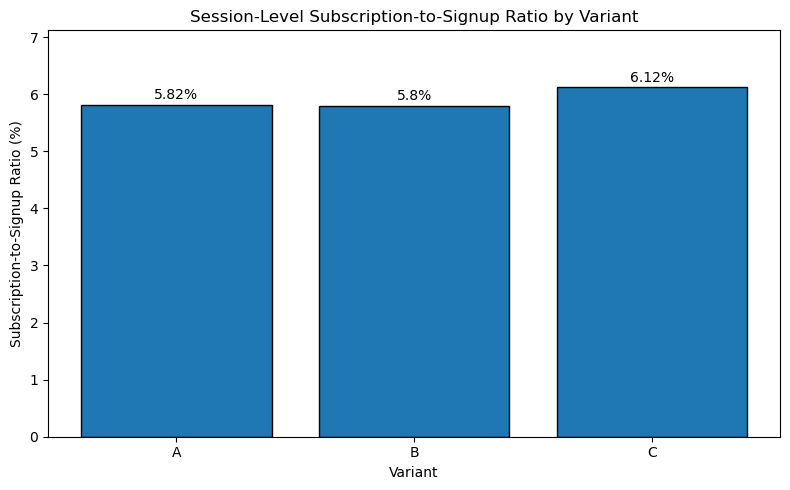

In [ ]:

# Plot session-level subscription-to-signup ratio by variant
plt.figure(figsize=(8, 5))
plt.bar(session_level_ratio['flag'], session_level_ratio['session_subscription_to_signup_ratio'], edgecolor='black')
plt.title('Session-Level Subscription-to-Signup Ratio by Variant')
plt.xlabel('Variant')
plt.ylabel('Subscription-to-Signup Ratio (%)')
plt.ylim(0, max(session_level_ratio['session_subscription_to_signup_ratio']) + 1)

for i, val in enumerate(session_level_ratio['session_subscription_to_signup_ratio']):
    plt.text(i, val + 0.1, f'{val}%', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
#calculating daily conversion rates across each variant for time series analysis
df_deduplicated['converted'] = (df_deduplicated['signups'] > 0).astype(int)

# Group by Date and flag, calculate daily conversion rate
daily_cr = (
    df_deduplicated.groupby(['Date', 'flag'])['converted']
    .mean()
    .mul(100)
    .reset_index(name='conversion_rate_pct')
)

# Pivot to have one column per variant
daily_cr_pivot = daily_cr.pivot(index='Date', columns='flag', values='conversion_rate_pct').rename(
    columns={'A': 'CR_A', 'B': 'CR_B', 'C': 'CR_C'}
)
daily_cr_pivot.round(2)

flag,CR_A,CR_B,CR_C
Date,,,
2025-03-26,25.72,24.51,26.26
2025-03-27,23.97,24.47,24.49
2025-03-28,24.34,24.49,24.77
2025-03-29,25.83,25.34,25.71
2025-03-30,26.36,25.90,26.37
2025-03-31,26.80,26.36,27.15
2025-04-01,26.92,26.62,26.47
2025-04-02,26.45,26.58,26.06
2025-04-03,25.87,25.86,25.32


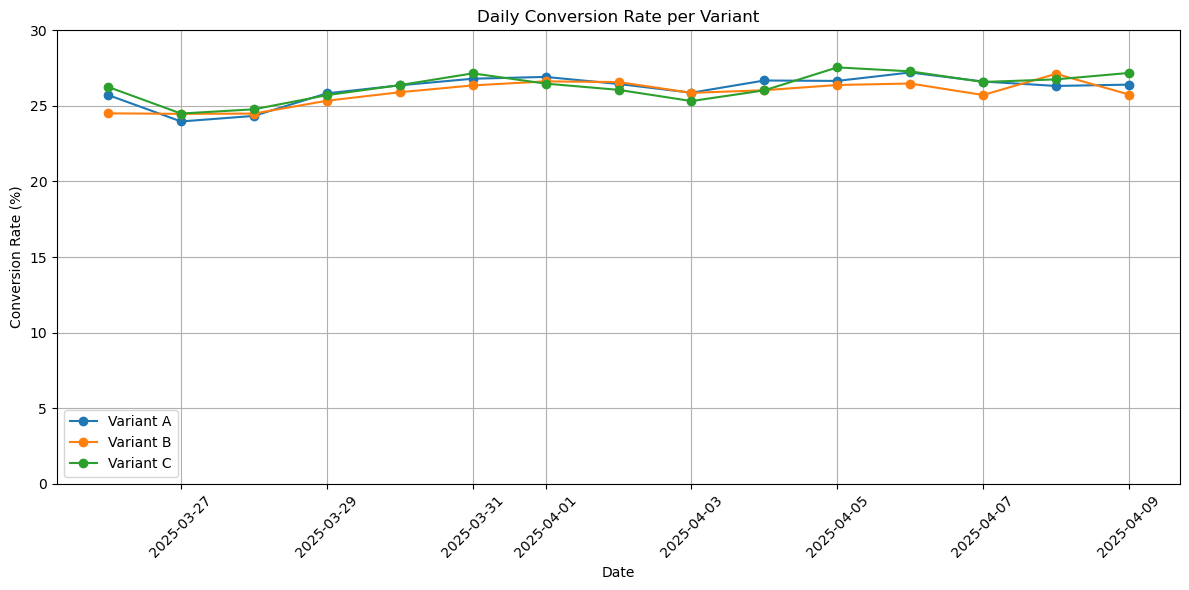

In [ ]:
#plot of time series line chart
plt.figure(figsize=(12, 6))
plt.plot(daily_cr_pivot.index, daily_cr_pivot['CR_A'], label='Variant A', marker='o')
plt.plot(daily_cr_pivot.index, daily_cr_pivot['CR_B'], label='Variant B', marker='o')
plt.plot(daily_cr_pivot.index, daily_cr_pivot['CR_C'], label='Variant C', marker='o')

plt.title('Daily Conversion Rate per Variant')
plt.xlabel('Date')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 30)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Add day of week and day type columns
df_deduplicated['day_of_week'] = df_deduplicated['Date'].dt.dayofweek
df_deduplicated['day_type'] = df_deduplicated['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Group by day type and variant to compute conversion rate
weekday_weekend_cr = (df_deduplicated.groupby(['day_type', 'flag'])['converted'].mean()
    .mul(100).reset_index(name='conversion_rate_pct')
    .pivot(index='day_type', columns='flag', values='conversion_rate_pct')
)

weekday_weekend_cr.round(2)

flag,A,B,C
day_type,,,
Weekday,26.01,25.85,26.03
Weekend,26.53,26.04,26.75


In [ ]:
# Identifying the maximum session duration outlier
max_duration = df_deduplicated['sessionDurationInSeconds'].max()

# Removing the max outlier
df_duration_cleaned = df_deduplicated[df_deduplicated['sessionDurationInSeconds'] < max_duration]

# Recalculating average session duration per variant without the max outlier
avg_session_duration_cleaned = (
    df_duration_cleaned.groupby('flag')['sessionDurationInSeconds'].mean().round(2)
    .reset_index(name='Avg Session Duration (seconds, no outlier)')
)

avg_session_duration_cleaned

,flag,"Avg Session Duration (seconds, no outlier)"
0,A,256.36
1,B,255.18
2,C,256.21


In [ ]:
df['subscriptionsTotalByCycle_clean'].value_counts(dropna=False)


subscriptionsTotalByCycle_clean
<NA>               606452
1: 1.0               7727
12: 1.0              2588
24: 1.0              1934
3: 1.0                145
1: 2.0                 17
12: 3.0                 4
1: 3.0                  3
1: 1.0, 12: 1.0         2
1: 5.0                  1
12: 2.0                 1
1: 1.0, 24: 1.0         1
Name: count, dtype: int64

In [ ]:
# Filtering only for rows with those specific plan value strings
target_plans = ['1: 1.0', '12: 1.0', '24: 1.0', '3: 1.0']
filtered_df = df_deduplicated[df_deduplicated['subscriptionsTotalByCycle_clean'].isin(target_plans)]

# Count occurrences by variant and plan
plan_distribution_by_variant = (
    filtered_df.groupby(['flag', 'subscriptionsTotalByCycle_clean']).size().reset_index(name='count'))

# Calculate total for each variant to compute % distribution
plan_distribution_by_variant['total_per_variant'] = plan_distribution_by_variant.groupby('flag')['count'].transform('sum')
plan_distribution_by_variant['percentage'] = (plan_distribution_by_variant['count'] / plan_distribution_by_variant['total_per_variant']) * 100
plan_distribution_by_variant['percentage'] = plan_distribution_by_variant['percentage'].round(2)

# Pivot for easy comparison
pivot_plan_dist_by_variant = plan_distribution_by_variant.pivot(
    index='subscriptionsTotalByCycle_clean',columns='flag',values='percentage').round(2)

pivot_plan_dist_by_variant

flag,A,B,C
subscriptionsTotalByCycle_clean,,,
12: 1.0,20.28,22.40,19.99
1: 1.0,63.55,62.26,61.31
24: 1.0,16.17,15.29,15.41
3: 1.0,NaN,0.05,3.29
